# IQ Dataset — quick test & visualization

This notebook loads `Real_usrp_39000_11class_raw.h5` using the `IQDataset` class in `dataset.py`,
prints a summary of the dataset, visualizes a few IQ samples, and builds train / val / test
PyTorch DataLoaders.

**Required files in the same folder:**
- `dataset.py`
- `Real_usrp_39000_11class_raw.h5`

**Dependencies:** `numpy`, `h5py`, `torch`, `matplotlib`.

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

from dataset import IQDataset, get_dataloaders

H5_PATH = "Real_usrp_39000_11class_raw.h5"
assert os.path.exists(H5_PATH), f"Put the .h5 file next to this notebook. Missing: {H5_PATH}"

## 1. Inspect the raw HDF5 file
Look at which keys exist and their shapes / dtypes — handy as a first sanity check.

In [2]:
with h5py.File(H5_PATH, "r") as f:
    print("Keys in file:")
    for k in f.keys():
        ds = f[k]
        print(f"  {k:>16}  shape={ds.shape}  dtype={ds.dtype}")

Keys in file:
    identification  shape=(429000,)  dtype=int32
                iq  shape=(429000, 512, 2)  dtype=float32
            iq_max  shape=(2,)  dtype=float32
            iq_min  shape=(2,)  dtype=float32
             label  shape=(429000,)  dtype=int32
            onehot  shape=(429000, 11)  dtype=float32
               snr  shape=(429000,)  dtype=int32
           snr_max  shape=()  dtype=int8
           snr_min  shape=()  dtype=int8


## 2. Load the dataset and print the summary

In [3]:
dataset = IQDataset(H5_PATH, normalize=True)
_ = dataset.summary()

File: Real_usrp_39000_11class_raw.h5
Samples (after filters): 429000
Signal length used: 512 (full length in file: 512)
IQ min  (I, Q): (-1.4000, -1.4183)
IQ max  (I, Q): (1.3796, 1.3815)
SNR range in file: [10, 10]
Identification range: [1, 429000]

Class distribution:
  [0] class_0: 39000
  [1] class_1: 39000
  [2] class_2: 39000
  [3] class_3: 39000
  [4] class_4: 39000
  [5] class_5: 39000
  [6] class_6: 39000
  [7] class_7: 39000
  [8] class_8: 39000
  [9] class_9: 39000
  [10] class_10: 39000

SNR distribution:
  SNR 10.0: 429000


## 3. Look at a single sample
Each item from the dataset is a dict with the IQ tensor and its metadata.

In [4]:
sample = dataset[0]
print({k: (tuple(v.shape) if hasattr(v, 'shape') else v) for k, v in sample.items()})
print("label =", sample["label"], "| snr =", sample["snr"], "| id =", sample["identification"])

{'iq': (2, 512), 'label': 10, 'snr': 10.0, 'identification': 1}
label = 10 | snr = 10.0 | id = 1


## 4. Visualize IQ waveforms (I and Q vs sample index)
We pick one sample per class so all classes are represented.

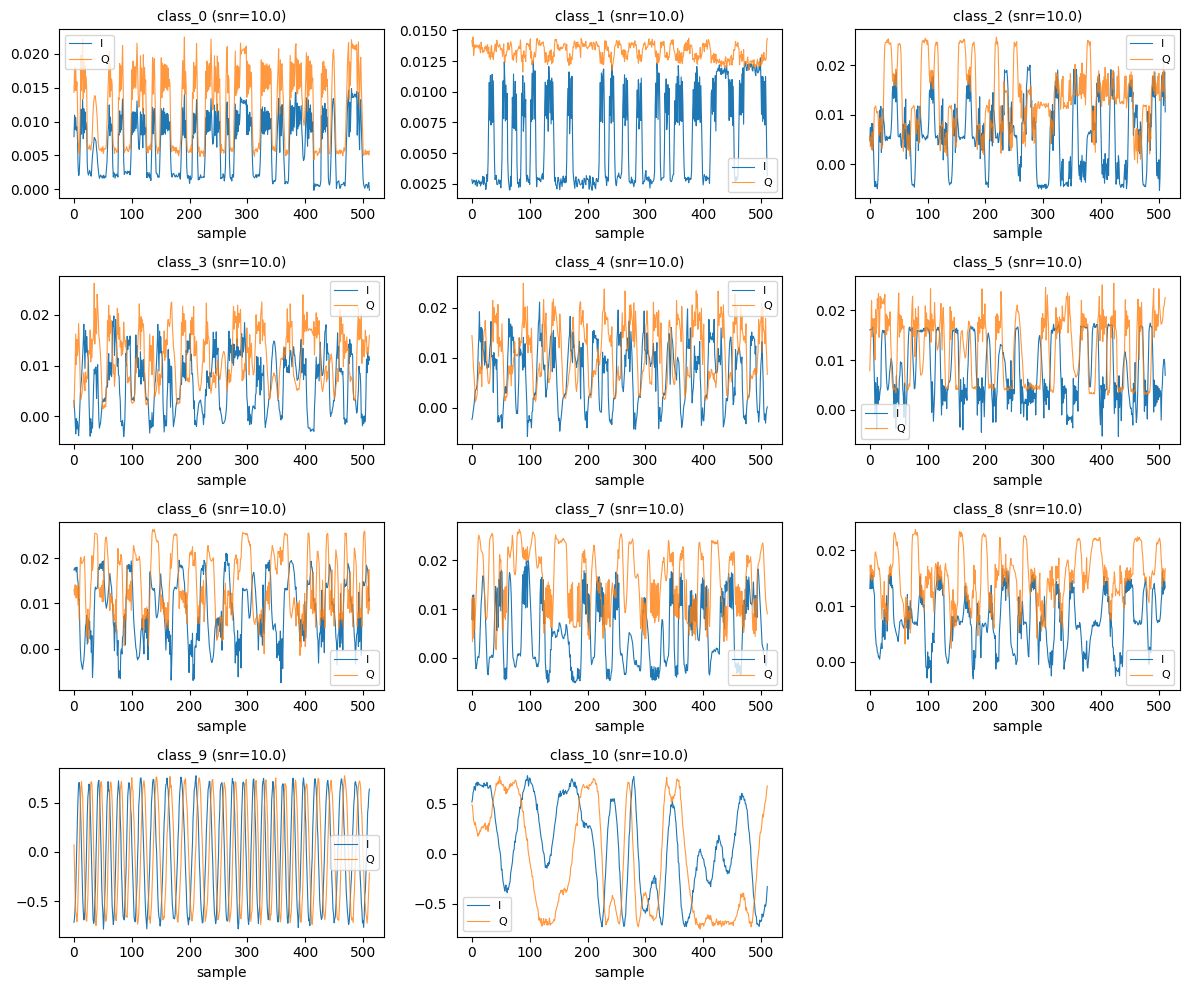

In [5]:
labels_arr = dataset.labels
unique_classes = np.unique(labels_arr)
n_classes = len(unique_classes)

n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, cls in zip(axes, unique_classes):
    idx = np.where(labels_arr == cls)[0][0]
    s = dataset[int(idx)]
    iq = s["iq"].numpy()                      # (2, L)
    ax.plot(iq[0], label="I", linewidth=0.8)
    ax.plot(iq[1], label="Q", linewidth=0.8, alpha=0.8)
    name = dataset.class_names[cls] if cls < len(dataset.class_names) else f"class_{cls}"
    ax.set_title(f"{name} (snr={s['snr']:.1f})", fontsize=10)
    ax.set_xlabel("sample")
    ax.legend(fontsize=8)

for ax in axes[len(unique_classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Constellation diagrams (I vs Q)

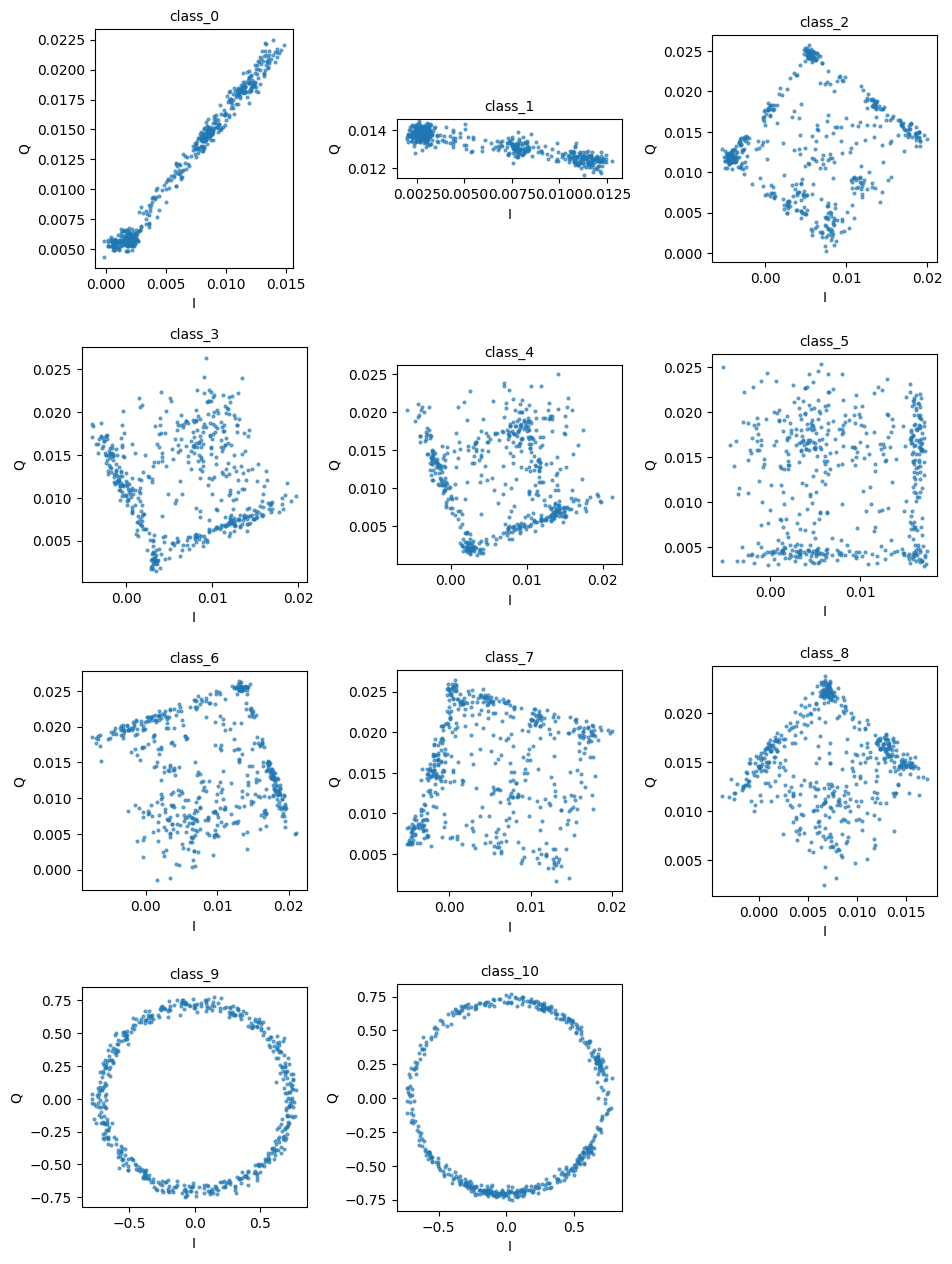

In [6]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, cls in zip(axes, unique_classes):
    idx = np.where(labels_arr == cls)[0][0]
    iq = dataset[int(idx)]["iq"].numpy()
    ax.scatter(iq[0], iq[1], s=4, alpha=0.6)
    name = dataset.class_names[cls] if cls < len(dataset.class_names) else f"class_{cls}"
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.set_aspect("equal", adjustable="box")

for ax in axes[len(unique_classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Class and SNR distributions

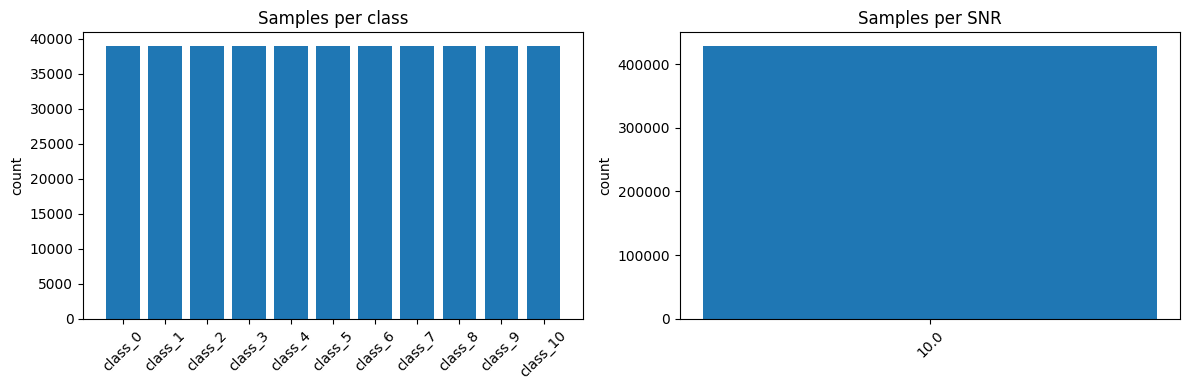

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

lbls, counts = np.unique(dataset.labels, return_counts=True)
names = [dataset.class_names[l] if l < len(dataset.class_names) else f"class_{l}" for l in lbls]
ax1.bar(names, counts)
ax1.set_title("Samples per class")
ax1.set_ylabel("count")
ax1.tick_params(axis="x", rotation=45)

snrs, snr_counts = np.unique(dataset.snr, return_counts=True)
ax2.bar([str(s) for s in snrs], snr_counts)
ax2.set_title("Samples per SNR")
ax2.set_ylabel("count")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Optional filters
Examples: keep only high-SNR samples, or keep only certain identification ranges.
Pass these directly when constructing `IQDataset`.

In [8]:
# Example 1: keep only samples with SNR in [10, 30)
ds_high_snr = IQDataset(H5_PATH, snr_range=(10, 30))
print(f"After SNR filter [10, 30): {len(ds_high_snr)} samples")

# Example 2: keep only some identification ranges
ds_by_id = IQDataset(H5_PATH, id_ranges=[(1, 200), (250, 300)])
print(f"After identification filter: {len(ds_by_id)} samples")

After SNR filter [10, 30): 429000 samples
After identification filter: 251 samples


## 8. Build train / val / test DataLoaders
Default split is 70 / 10 / 20.

In [9]:
train_loader, val_loader, test_loader = get_dataloaders(
    dataset, batch_size=64, train_ratio=0.7, val_ratio=0.1, shuffle=True
)

batch = next(iter(train_loader))
print("Batch keys:", list(batch.keys()))
print("  iq             shape:", tuple(batch["iq"].shape), "dtype:", batch["iq"].dtype)
print("  label          shape:", tuple(batch["label"].shape))
print("  snr            shape:", tuple(batch["snr"].shape))
print("  identification shape:", tuple(batch["identification"].shape))

Train: 300300 | Val: 42900 | Test: 85800
Batch keys: ['iq', 'label', 'snr', 'identification']
  iq             shape: (64, 2, 512) dtype: torch.float32
  label          shape: (64,)
  snr            shape: (64,)
  identification shape: (64,)


Done. The dataset loads correctly, samples have the expected shape `(2, L)`, and the
DataLoaders are ready to plug into a training loop.